
# ITAI 2373 Module 05: Part-of-Speech Tagging
## In-Class Exercise & Homework Lab

Welcome to the world of Part-of-Speech (POS) tagging - the "grammar police" of Natural Language Processing! 🚔📝

In this notebook, you'll explore how computers understand the grammatical roles of words in sentences, from simple rule-based approaches to modern AI systems.

### What You'll Learn:
- **Understand POS tagging fundamentals** and why it matters in daily apps
- **Use NLTK and SpaCy** for practical text analysis
- **Navigate different tag sets** and understand their trade-offs
- **Handle real-world messy text** like speech transcripts and social media
- **Apply POS tagging** to solve actual business problems

### Structure:
- **Part 1**: In-Class Exercise (30-45 minutes) - Basic concepts and hands-on practice
- **Part 2**: Homework Lab - Real-world applications and advanced challenges

---

*💡 **Pro Tip**: POS tagging is everywhere! It helps search engines understand "Apple stock" vs "apple pie", helps Siri understand your commands, and powers autocorrect on your phone.*



## 🛠️ Setup and Installation

Let's get our tools ready! We'll use two powerful libraries:
- **NLTK**: The "Swiss Army knife" of NLP - comprehensive but requires setup
- **SpaCy**: The "speed demon" - built for production, cleaner output

Run the cells below to install and set up everything we need.


In [ ]:

# Install required libraries (run this first!)
!pip install nltk spacy matplotlib seaborn pandas
!python -m spacy download en_core_web_sm

print("✅ Installation complete!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 75.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Installation complete!


In [ ]:

# Import all the libraries we'll need
import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (this might take a moment)
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('universal_tagset')

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

print("🎉 All libraries loaded successfully!")
print("📚 NLTK version:", nltk.__version__)
print("🚀 SpaCy version:", spacy.__version__)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.


🎉 All libraries loaded successfully!
📚 NLTK version: 3.9.1
🚀 SpaCy version: 3.8.14



---
# 🎯 PART 1: IN-CLASS EXERCISE (30-45 minutes)

Welcome to the hands-on portion! We'll start with the basics and build up your understanding step by step.

## Learning Goals for Part 1:
1. Understand what POS tagging does
2. Use NLTK and SpaCy for basic tagging
3. Interpret and compare different tag outputs
4. Explore word ambiguity with real examples
5. Compare different tagging approaches



## 🔍 Activity 1: Your First POS Tags (10 minutes)

Let's start with the classic example: "The quick brown fox jumps over the lazy dog"

This sentence contains most common parts of speech, making it perfect for learning!


In [ ]:
import nltk

# Ensure the necessary NLTK resources are downloaded
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

# Let's start with a classic example
sentence = "The quick brown fox jumps over the lazy dog"

# TODO: Use NLTK to tokenize and tag the sentence
# Hint: Use nltk.word_tokenize() and nltk.pos_tag()
tokens = nltk.word_tokenize(sentence)
pos_tags = nltk.pos_tag(tokens)

print("Original sentence:", sentence)
print("\nTokens:", tokens)
print("\nPOS Tags:")
for word, tag in pos_tags:
    print(f"  {word:8} -> {tag}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Original sentence: The quick brown fox jumps over the lazy dog

Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

POS Tags:
  The      -> DT
  quick    -> JJ
  brown    -> NN
  fox      -> NN
  jumps    -> VBZ
  over     -> IN
  the      -> DT
  lazy     -> JJ
  dog      -> NN



### 🤔 Quick Questions:
1. What does 'DT' mean? What about 'JJ'?
2. Why do you think 'brown' and 'lazy' have the same tag?
3. Can you guess what 'VBZ' represents?

A1. DT is a determiner word, which introduces a noun to the sentence, while J is an adjective, which describes the noun.

A2. "Brown" and "Lazy" probably have the same tag because they are used in similar ways: as adjectives.

A3. VBZ probably represents verbs.

*Hint: Think about the grammatical role each word plays in the sentence!*



## 🚀 Activity 2: SpaCy vs NLTK Showdown (10 minutes)

Now let's see how SpaCy handles the same sentence. SpaCy uses cleaner, more intuitive tag names.


In [ ]:
import spacy
nlp = spacy.load('en_core_web_sm')

# TODO: Process the same sentence with SpaCy
# Hint: Use nlp(sentence) and access .text and .pos_ attributes
doc = nlp(sentence)

print("SpaCy POS Tags:")
for token in doc:
    print(f"  {token.text:8} -> {token.pos_:6} ({token.tag_})")

print("\n" + "="*50)
print("COMPARISON:")
print("="*50)

# Let's compare side by side
nltk_tags = nltk.pos_tag(nltk.word_tokenize(sentence))
spacy_doc = nlp(sentence)

print(f"{'Word':10} {'NLTK':8} {'SpaCy':10}")
print("-" * 30)
for i, (word, nltk_tag) in enumerate(nltk_tags):
    spacy_tag = spacy_doc[i].pos_
    print(f"{word:10} {nltk_tag:8} {spacy_tag:10}")

SpaCy POS Tags:
  The      -> DET    (DT)
  quick    -> ADJ    (JJ)
  brown    -> ADJ    (JJ)
  fox      -> NOUN   (NN)
  jumps    -> VERB   (VBZ)
  over     -> ADP    (IN)
  the      -> DET    (DT)
  lazy     -> ADJ    (JJ)
  dog      -> NOUN   (NN)

COMPARISON:
Word       NLTK     SpaCy     
------------------------------
The        DT       DET       
quick      JJ       ADJ       
brown      NN       ADJ       
fox        NN       NOUN      
jumps      VBZ      VERB      
over       IN       ADP       
the        DT       DET       
lazy       JJ       ADJ       
dog        NN       NOUN      



### 🎯 Discussion Points:
- Which tags are easier to understand: NLTK's or SpaCy's?
- Do you notice any differences in how they tag the same words?
- Which system would you prefer for a beginner? Why?

A1. SpaCy's tags are easier to understand, since they represent more understandable abbreviations.

A2. Some nouns are classified as adjectives, like "brown", since the word "brown" can be both a noun and an adjective, but most scenarios see the word as an adjective.

A3. As a beginner, I prefer SpaCy's tags, since they were easier to understand and easier to apply to grammatical concepts.


## 🎭 Activity 3: The Ambiguity Challenge (15 minutes)

Here's where things get interesting! Many words can be different parts of speech depending on context. Let's explore this with some tricky examples.


In [ ]:

# Ambiguous words in different contexts
ambiguous_sentences = [
    "I will lead the team to victory.",           # lead = verb
    "The lead pipe is heavy.",                    # lead = noun (metal)
    "She took the lead in the race.",            # lead = noun (position)
    "The bank approved my loan.",                # bank = noun (financial)
    "We sat by the river bank.",                 # bank = noun (shore)
    "I bank with Chase.",                        # bank = verb
    "The plane landed at the airport.",
    "Please point at the plane facing the Z-direction."
]

print("🎭 AMBIGUITY EXPLORATION")
print("=" * 40)

for sentence in ambiguous_sentences:
    print(f"\nSentence: {sentence}")

    # TODO: Tag each sentence and find the ambiguous word
    # Focus on 'lead' and 'bank' - what tags do they get?
    tokens = nltk.word_tokenize(sentence)
    tags = nltk.pos_tag(tokens)

    # Find and highlight the key word
    for word, tag in tags:
        if word.lower() in ['lead', 'bank', 'plane']:
            print(f"  🎯 '{word}' is tagged as: {tag}")


🎭 AMBIGUITY EXPLORATION

Sentence: I will lead the team to victory.
  🎯 'lead' is tagged as: VB

Sentence: The lead pipe is heavy.
  🎯 'lead' is tagged as: NN

Sentence: She took the lead in the race.
  🎯 'lead' is tagged as: NN

Sentence: The bank approved my loan.
  🎯 'bank' is tagged as: NN

Sentence: We sat by the river bank.
  🎯 'bank' is tagged as: NN

Sentence: I bank with Chase.
  🎯 'bank' is tagged as: NN

Sentence: The plane landed at the airport.
  🎯 'plane' is tagged as: NN

Sentence: Please point at the plane facing the Z-direction.
  🎯 'plane' is tagged as: NN



### 🧠 Think About It:
1. How does the computer know the difference between "lead" (metal) and "lead" (guide)?
2. What clues in the sentence help determine the correct part of speech?
3. Can you think of other words that change meaning based on context?

A1. The computer looks at the surrounding words and analyzes the context of the sentence to differentiate the words.

A2. Other nouns or adjectives in the sentence may help identify which variation of the word is being used.

A3. The word "plane" could refer to the aerial vehicle, or to a surface on a 3D object.

**Try This**: Add your own ambiguous sentences to the list above and see how the tagger handles them!



## 📊 Activity 4: Tag Set Showdown (10 minutes)

NLTK can use different tag sets. Let's compare the detailed Penn Treebank tags (~45 tags) with the simpler Universal Dependencies tags (~17 tags).


In [ ]:
import nltk
from collections import Counter

# Ensure the necessary NLTK resources are available
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('universal_tagset')

# Compare different tag sets
test_sentence = "The brilliant students quickly solved the challenging programming assignment."

# Get tags using both Penn Treebank and Universal tagsets
tokens = nltk.word_tokenize(test_sentence)
penn_tags = nltk.pos_tag(tokens)
universal_tags = nltk.pos_tag(tokens, tagset='universal')

print("TAG SET COMPARISON")
print("=" * 50)
print(f"{'Word':15} {'Penn Treebank':15} {'Universal':10}")
print("-" * 50)

# Print comparison table by zipping the two tagged lists
for (word, penn_tag), (_, univ_tag) in zip(penn_tags, universal_tags):
    print(f"{word:15} {penn_tag:15} {univ_tag:10}")

# Visualize the tag distribution
penn_tag_counts = Counter([tag for word, tag in penn_tags])
univ_tag_counts = Counter([tag for word, tag in universal_tags])

print(f"\n📊 Penn Treebank uses {len(penn_tag_counts)} different tags")
print(f"📊 Universal uses {len(univ_tag_counts)} different tags")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...


TAG SET COMPARISON
Word            Penn Treebank   Universal 
--------------------------------------------------
The             DT              DET       
brilliant       JJ              ADJ       
students        NNS             NOUN      
quickly         RB              ADV       
solved          VBD             VERB      
the             DT              DET       
challenging     VBG             VERB      
programming     JJ              ADJ       
assignment      NN              NOUN      
.               .               .         

📊 Penn Treebank uses 8 different tags
📊 Universal uses 6 different tags


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!



### 🤔 Reflection Questions:
1. Which tag set is more detailed? Which is simpler? Enter your answer below

2. When might you want detailed tags vs. simple tags? Enter your answer below

3. If you were building a search engine, which would you choose? Why? Enter your answer below

A1. The Penn Treebank tag set is more detailed, and the Universal tag set is simpler.

A2. For larger sets of text, the Universal tag set would be better to use. For smaller sets of text, Penn Treebank tag set is preferred.

A3. The best tag set for a search engine would probably be the Penn Treebank, since it is much more detailed and can handle different meanings for the same word.

---



---
# 🎓 End of Part 1: In-Class Exercise

Great work! You've learned the fundamentals of POS tagging and gotten hands-on experience with both NLTK and SpaCy.

## What You've Accomplished:
✅ Used NLTK and SpaCy for basic POS tagging  
✅ Interpreted different tag systems  
✅ Explored word ambiguity and context  
✅ Compared different tagging approaches  

## 🏠 Ready for Part 2?
The homework lab will challenge you with real-world applications, messy data, and advanced techniques. You'll analyze customer service transcripts, handle informal language, and benchmark different taggers.

**Take a break, then dive into Part 2 when you're ready!**

---



# 🏠 PART 2: HOMEWORK LAB
## Real-World POS Tagging Challenges

Welcome to the advanced section! Here you'll tackle the messy, complex world of real text data. This is where POS tagging gets interesting (and challenging)!

## Learning Goals for Part 2:
1. Process real-world, messy text data
2. Handle speech transcripts and informal language
3. Analyze customer service scenarios
4. Benchmark and compare different taggers
5. Understand limitations and edge cases

## 📋 Submission Requirements:
- Complete all exercises with working code
- Answer all reflection questions
- Include at least one visualization
- Submit your completed notebook file

---



## 🌍 Lab Exercise 1: Messy Text Challenge (25 minutes)

Real-world text is nothing like textbook examples! Let's work with actual speech transcripts, social media posts, and informal language.


In [ ]:
import nltk
import spacy

# Load SpaCy model if not already loaded
try:
    nlp
except NameError:
    nlp = spacy.load('en_core_web_sm')

# Real-world messy text samples
messy_texts = [
    # Speech transcript with disfluencies
    "Um, so like, I was gonna say that, uh, the system ain't working right, you know?",

    # Social media style
    "OMG this app is sooo buggy rn 😤 cant even login smh",

    # Customer service transcript
    "Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working",

    # Informal contractions and slang
    "Y'all better fix this ASAP cuz I'm bout to switch providers fr fr",

    # Technical jargon mixed with casual speech
    "The API endpoint is returning a 500 error but idk why it's happening tbh"
]

print("🔍 PROCESSING MESSY TEXT")
print("=" * 60)

for i, text in enumerate(messy_texts, 1):
    print(f"\n📝 Sample {i}: {text}")
    print("-" * 40)

    # NLTK processing
    nltk_tokens = nltk.word_tokenize(text)
    nltk_tags = nltk.pos_tag(nltk_tokens)

    # SpaCy processing
    spacy_doc = nlp(text)

    # Expanded definitions for 'problematic' words in messy text:
    # NLTK: include X (unknown), SYM (symbols), UH (interjections/fillers), FW (foreign/slang)
    problematic_nltk = [word for word, tag in nltk_tags if tag in ['X', 'SYM', 'UH', 'FW']]

    # SpaCy: include X (unknown), SYM (symbols), INTJ (interjections)
    problematic_spacy = [token.text for token in spacy_doc if token.pos_ in ['X', 'SYM', 'INTJ']]

    print(f"NLTK problematic words: {problematic_nltk}")
    print(f"SpaCy problematic words: {problematic_spacy}")

    # Calculate success rate based on these findings
    nltk_success_rate = (len(nltk_tags) - len(problematic_nltk)) / len(nltk_tags) if len(nltk_tags) > 0 else 0
    spacy_success_rate = (len(spacy_doc) - len(problematic_spacy)) / len(spacy_doc) if len(spacy_doc) > 0 else 0

    print(f"NLTK success rate: {nltk_success_rate:.1%}")
    print(f"SpaCy success rate: {spacy_success_rate:.1%}")

🔍 PROCESSING MESSY TEXT

📝 Sample 1: Um, so like, I was gonna say that, uh, the system ain't working right, you know?
----------------------------------------
NLTK problematic words: ['uh']
SpaCy problematic words: ['Um', 'like', 'uh']
NLTK success rate: 95.8%
SpaCy success rate: 87.5%

📝 Sample 2: OMG this app is sooo buggy rn 😤 cant even login smh
----------------------------------------
NLTK problematic words: []
SpaCy problematic words: []
NLTK success rate: 100.0%
SpaCy success rate: 100.0%

📝 Sample 3: Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working
----------------------------------------
NLTK problematic words: ['Yeah']
SpaCy problematic words: ['Yeah', 'hi', 'um', 'like']
NLTK success rate: 96.6%
SpaCy success rate: 86.2%

📝 Sample 4: Y'all better fix this ASAP cuz I'm bout to switch providers fr fr
----------------------------------------
NLTK problematic words: []
SpaCy problem


### 🎯 Analysis Questions:
1. Which tagger handles informal language better?
2. What types of words cause the most problems?
3. How might you preprocess text to improve tagging accuracy?
4. What are the implications for real-world applications?

A1. NLTK appeared to handle the problematic language better than SpaCy.

A2. Interjections and filler words had caused the most problems, specifically for SpaCy.

A3. We could remove these problematic words or symbols to improve the accuracy of tagging.

A4. Real-world applications must be able to handle all types of problematic text/symbols in order to be as effective and accurate as possible. Systems like search engines or chatbots require this type of precise handling.


## 📞 Lab Exercise 2: Customer Service Analysis Case Study (30 minutes)

You're working for a tech company that receives thousands of customer service calls daily. Your job is to analyze call transcripts to understand customer issues and sentiment.

**Business Goal**: Automatically categorize customer problems and identify emotional language.


In [ ]:
import spacy

# Ensure the SpaCy model is loaded to avoid NameError
try:
    nlp
except NameError:
    nlp = spacy.load('en_core_web_sm')

# Simulated customer service call transcripts
customer_transcripts = [
    {
        'id': 'CALL_001',
        'transcript': "Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.",
        'category': 'account_access'
    },
    {
        'id': 'CALL_002',
        'transcript': "Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?",
        'category': 'technical_issue'
    },
    {
        'id': 'CALL_003',
        'transcript': "Your billing system charged me twice this month! I want a refund immediately. This is ridiculous and I'm considering canceling my subscription.",
        'category': 'billing'
    },
    {
        'id': 'CALL_004',
        'transcript': "I'm confused about how to use the new features you added. The interface changed and I can't find anything. Can someone walk me through it?",
        'category': 'user_guidance'
    }
]

# Define keyword lists for sentiment and urgency
pos_list = ['love', 'help', 'great', 'good', 'happy', 'thanks']
neg_list = ['frustrated', 'unacceptable', 'ridiculous', 'cancel', 'issue', 'crash', 'confused']
urgent_list = ['immediately', 'asap', 'hours', 'twice']

analysis_results = []

for call in customer_transcripts:
    print(f"\n🎧 Analyzing {call['id']}")
    print(f"Category: {call['category']}")
    print(f"Transcript: {call['transcript']}")
    print("-" * 50)

    # Process with SpaCy
    doc = nlp(call['transcript'].lower())

    # Extract different types of words
    emotional_adjectives = [token.text for token in doc if token.pos_ == 'ADJ']
    action_verbs = [token.lemma_ for token in doc if token.pos_ == 'VERB']
    problem_nouns = [chunk.text for chunk in doc.noun_chunks if any(p in chunk.text.lower() for p in ['account', 'system', 'app', 'file', 'feature', 'issue'])]

    # Calculate sentiment indicators
    positive_words = [token.text for token in doc if token.text in pos_list]
    negative_words = [token.text for token in doc if token.text in neg_list]
    urgency_count = sum(1 for token in doc if token.text in urgent_list)

    result = {
        'call_id': call['id'],
        'category': call['category'],
        'emotional_adjectives': emotional_adjectives,
        'action_verbs': action_verbs,
        'problem_nouns': problem_nouns,
        'sentiment_score': len(positive_words) - len(negative_words),
        'urgency_indicators': urgency_count
    }

    analysis_results.append(result)

    print(f"Emotional adjectives: {emotional_adjectives}")
    print(f"Action verbs: {action_verbs}")
    print(f"Problem nouns: {problem_nouns}")
    print(f"Sentiment score: {result['sentiment_score']}")
    print(f"Urgency score: {result['urgency_indicators']}")


🎧 Analyzing CALL_001
Category: account_access
Transcript: Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.
--------------------------------------------------
Emotional adjectives: ['frustrated', 'unacceptable']
Action verbs: ['lock', 'access', 'try', 'work']
Problem nouns: ['my account', 'my files']
Sentiment score: -2
Urgency score: 1

🎧 Analyzing CALL_002
Category: technical_issue
Transcript: Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?
--------------------------------------------------
Emotional adjectives: ['small', 'mobile']
Action verbs: ['love', 'have', 'crash', 'try', 'upload', 'help', 'fix']
Problem nouns: ['a small issue', 'the mobile app']
Sentiment score: 1
Urgency score: 0

🎧 Analyzing CALL_003
Category: billing
Transcript: Your billing system charge

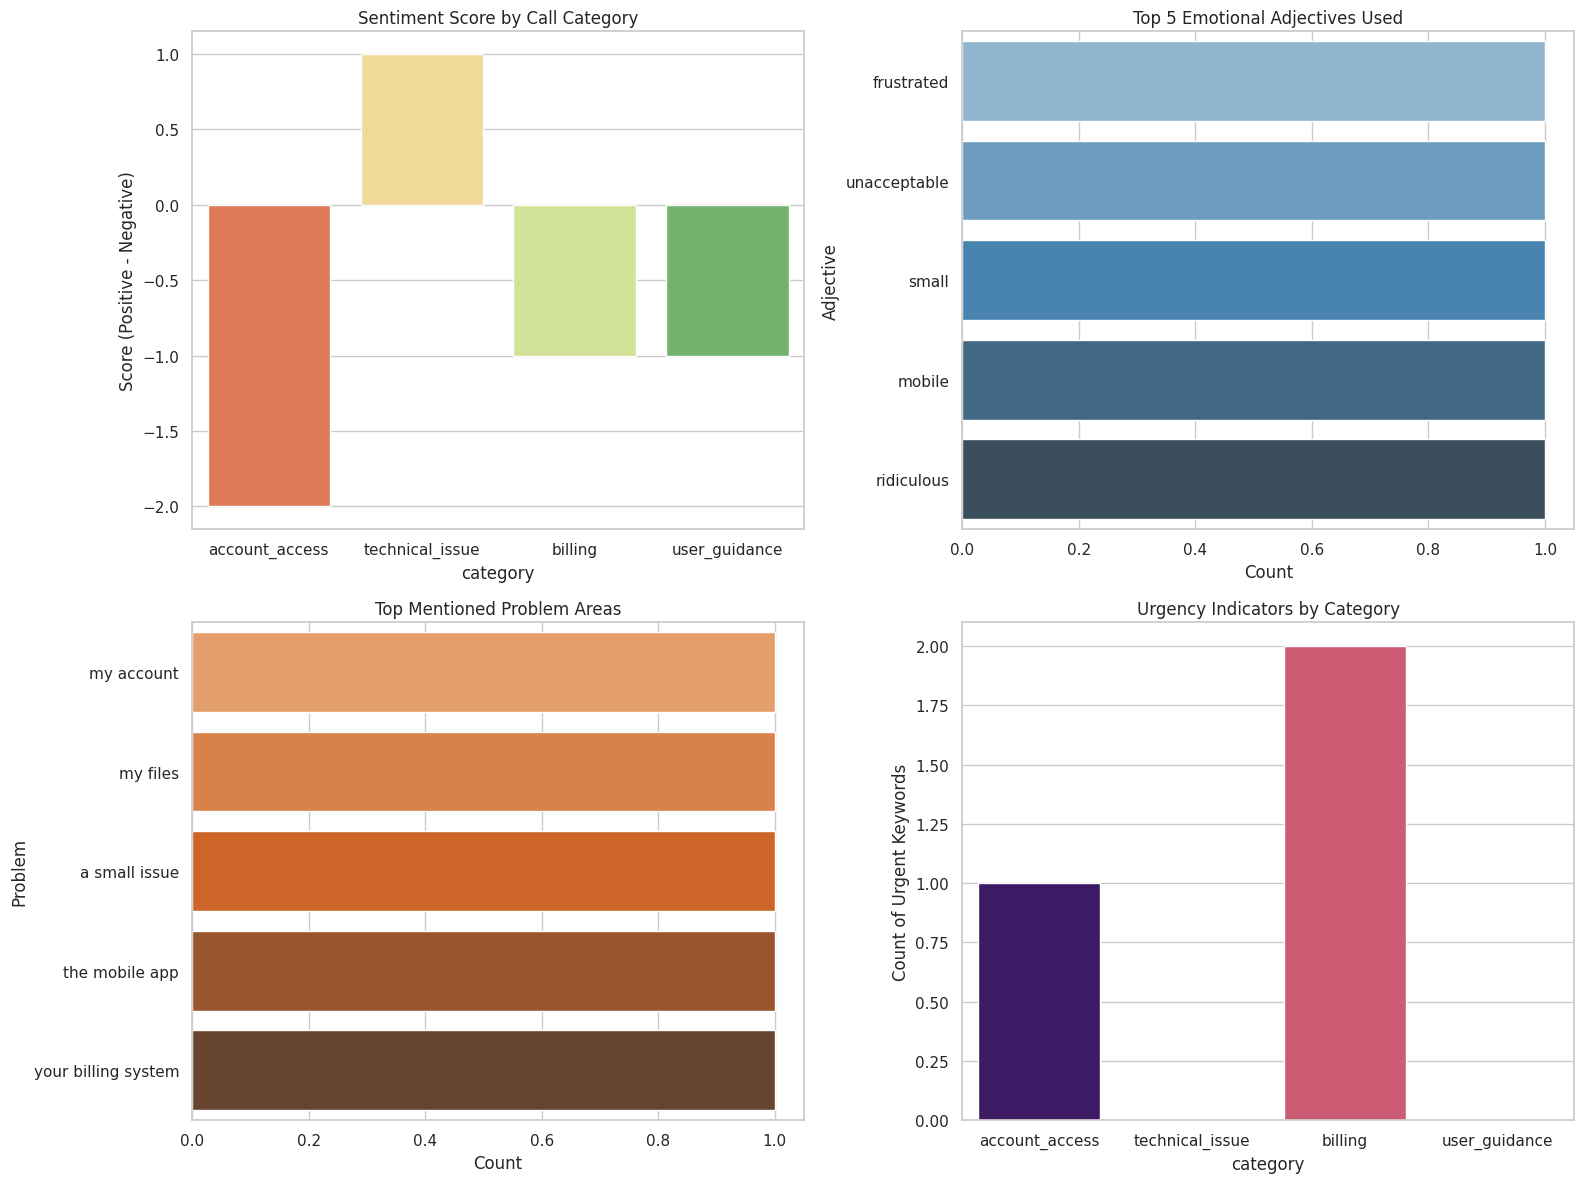

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter

# Convert results to DataFrame
df = pd.DataFrame(analysis_results)

# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Sentiment by Category
sns.barplot(ax=axes[0, 0], x='category', y='sentiment_score', data=df, palette='RdYlGn', hue='category', legend=False)
axes[0, 0].set_title('Sentiment Score by Call Category')
axes[0, 0].set_ylabel('Score (Positive - Negative)')

# 2. Most Common Emotional Adjectives
all_adj = [adj for sublist in df['emotional_adjectives'] for adj in sublist]
adj_counts = Counter(all_adj).most_common(5)
if adj_counts:
    adj_df = pd.DataFrame(adj_counts, columns=['Adjective', 'Count'])
    sns.barplot(ax=axes[0, 1], x='Count', y='Adjective', data=adj_df, palette='Blues_d', hue='Adjective', legend=False)
axes[0, 1].set_title('Top 5 Emotional Adjectives Used')

# 3. Problem Categorization (Frequency of nouns detected)
all_problems = [prob for sublist in df['problem_nouns'] for prob in sublist]
prob_counts = Counter(all_problems).most_common(5)
if prob_counts:
    prob_df = pd.DataFrame(prob_counts, columns=['Problem', 'Count'])
    sns.barplot(ax=axes[1, 0], x='Count', y='Problem', data=prob_df, palette='Oranges_d', hue='Problem', legend=False)
axes[1, 0].set_title('Top Mentioned Problem Areas')

# 4. Urgency Analysis
sns.barplot(ax=axes[1, 1], x='category', y='urgency_indicators', data=df, palette='magma', hue='category', legend=False)
axes[1, 1].set_title('Urgency Indicators by Category')
axes[1, 1].set_ylabel('Count of Urgent Keywords')

plt.tight_layout()
plt.show()


### 💼 Business Impact Questions:
1. How could this analysis help prioritize customer service tickets?
2. What patterns do you notice in different problem categories?
3. How might you automate the routing of calls based on POS analysis?
4. What are the limitations of this approach?

A1. With this analysis, customer service tickets would be able to be prioritized by urgency.

A2. According to the graphs, most of the urgent tickets have to do with account access or billing.

A3. You could implement a system where the calls would be sorted by urgency or sentiment via POS analysis.

A4. Some calls may be prioritized incorrectly based on false urgencies or exaggerated sentiment.


## ⚡ Lab Exercise 3: Tagger Performance Benchmarking (20 minutes)

Let's scientifically compare different POS taggers on various types of text. This will help you understand when to use which tool.


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!



🧪 Testing FORMAL text:
NLTK Penn: 0.0009s | SpaCy: 0.0091s

🧪 Testing INFORMAL text:
NLTK Penn: 0.0009s | SpaCy: 0.0071s

🧪 Testing TECHNICAL text:
NLTK Penn: 0.0009s | SpaCy: 0.0085s

🧪 Testing CONVERSATIONAL text:
NLTK Penn: 0.0011s | SpaCy: 0.0085s

🧪 Testing MIXED text:
NLTK Penn: 0.0017s | SpaCy: 0.0086s


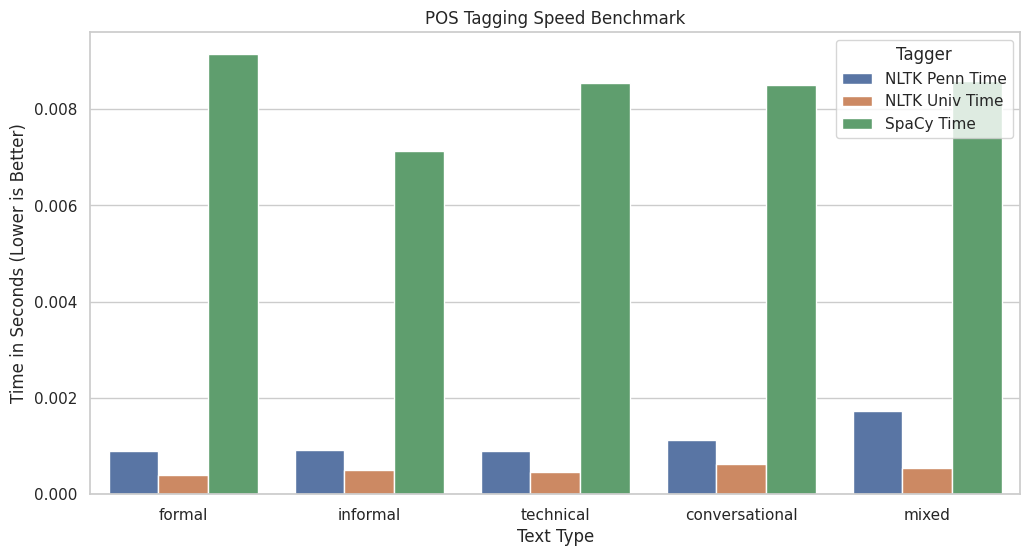

,Text Type,NLTK Unknown,SpaCy Unknown
0,formal,0,0
1,informal,0,0
2,technical,0,0
3,conversational,0,1
4,mixed,0,0


In [ ]:
import time
from collections import defaultdict
import nltk
import spacy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Fix: Download required NLTK resources to prevent LookupError
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('universal_tagset')

# Ensure models are loaded
try:
    nlp
except NameError:
    nlp = spacy.load('en_core_web_sm')

# Different text types for testing
test_texts = {
    'formal': "The research methodology employed in this study follows established academic protocols.",
    'informal': "lol this study is kinda weird but whatever works i guess",
    'technical': "The API returns a JSON response with HTTP status code 200 upon successful authentication.",
    'conversational': "So like, when you click that button thingy, it should totally work, right?",
    'mixed': "OMG the algorithm's performance is absolutely terrible! The accuracy dropped to 23% wtf"
}

benchmark_results = []

for text_type, text in test_texts.items():
    # Sanitize text to avoid Unicode surrogate errors
    clean_text = text.encode('utf-8', 'ignore').decode('utf-8')
    print(f"\n🧪 Testing {text_type.upper()} text:")

    # 1. NLTK Penn Treebank timing
    start_time = time.time()
    tokens = nltk.word_tokenize(clean_text)
    penn_tags = nltk.pos_tag(tokens)
    nltk_penn_time = time.time() - start_time

    # 2. NLTK Universal timing
    start_time = time.time()
    univ_tags = nltk.pos_tag(tokens, tagset='universal')
    nltk_univ_time = time.time() - start_time

    # 3. SpaCy timing
    start_time = time.time()
    doc = nlp(clean_text)
    spacy_time = time.time() - start_time

    # Count unknown/problematic tags (symbols, unknown, interjections)
    nltk_unknown = sum(1 for w, t in penn_tags if t in ['LS', 'SYM', 'UH'])
    spacy_unknown = sum(1 for token in doc if token.pos_ in ['X', 'SYM', 'INTJ'])

    benchmark_results.append({
        'Text Type': text_type,
        'NLTK Penn Time': nltk_penn_time,
        'NLTK Univ Time': nltk_univ_time,
        'SpaCy Time': spacy_time,
        'NLTK Unknown': nltk_unknown,
        'SpaCy Unknown': spacy_unknown
    })

    print(f"NLTK Penn: {nltk_penn_time:.4f}s | SpaCy: {spacy_time:.4f}s")

# Create performance comparison visualization
bench_df = pd.DataFrame(benchmark_results)
plot_df = bench_df.melt(id_vars='Text Type', value_vars=['NLTK Penn Time', 'NLTK Univ Time', 'SpaCy Time'],
                         var_name='Tagger', value_name='Time (s)')

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Text Type', y='Time (s)', hue='Tagger')
plt.title('POS Tagging Speed Benchmark')
plt.ylabel('Time in Seconds (Lower is Better)')
plt.show()

display(bench_df[['Text Type', 'NLTK Unknown', 'SpaCy Unknown']])


### 📊 Performance Analysis:
1. Which tagger is fastest? Does speed matter for your use case?
2. Which handles informal text best?
3. How do the taggers compare on technical jargon?
4. What trade-offs do you see between speed and accuracy?

A1. NLTK's Univeral tagger had the highest speeds. For my case, speed wasn't a major priority. Accuracy was prioritized.

A2. NLTK's Universal tagger handled the informal text the best.

A3. While NLTK's Universal handles technical jargon the fastest, it may not be as accurate when compared to SpaCy's tagger or NLTK's Penn Tree tagger.

A4. Like stated in the previous answer, speed may come at the cost of accuracy, or vice versa. Some taggers may process text very quickly, but may produce inaccuracies, while other taggers may process text slowly but produce much more accurate results.


## 🚨 Lab Exercise 4: Edge Cases and Error Analysis (15 minutes)

Every system has limitations. Let's explore the edge cases where POS taggers struggle and understand why.


In [ ]:
# Challenging edge cases
edge_cases = [
    "Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.",  # Famous ambiguous sentence
    "Time flies like an arrow; fruit flies like a banana.",              # Classic ambiguity
    "The man the boat the river.",                                       # Garden path sentence
    "Police police Police police police police Police police.",          # Recursive structure
    "James while John had had had had had had had had had had had a better effect on the teacher.",  # Had had had...
    "Can can can can can can can can can can.",                         # Modal/noun ambiguity
    "@username #hashtag http://bit.ly/abc123 😂🔥💯",                   # Social media elements
    "COVID-19 AI/ML IoT APIs RESTful microservices",                    # Modern technical terms
]

print("🚨 EDGE CASE ANALYSIS")
print("=" * 50)

for i, text in enumerate(edge_cases, 1):
    print(f"\n🔍 Edge Case {i}:")
    print(f"Text: {text}")
    print("-" * 30)

    try:
        # Process with NLTK
        tokens = nltk.word_tokenize(text)
        nltk_tags = nltk.pos_tag(tokens)

        # Process with SpaCy
        spacy_doc = nlp(text)

        print("NLTK tags:", [(w, t) for w, t in nltk_tags])
        print("SpaCy tags:", [(token.text, token.pos_) for token in spacy_doc])

        # Simple error detection: Check if a word is tagged as a symbol or unknown
        nltk_issues = [w for w, t in nltk_tags if t in ['SYM', 'X', 'UH']]
        spacy_issues = [t.text for t in spacy_doc if t.pos_ in ['SYM', 'X', 'INTJ']]

        if nltk_issues or spacy_issues:
            print(f"⚠️ Potential issues found in NLTK: {nltk_issues} or SpaCy: {spacy_issues}")

    except Exception as e:
        print(f"❌ Error processing: {e}")

# Reflection on limitations
print("\n🤔 REFLECTION ON LIMITATIONS:")
print("=" * 40)
print("1. Semantic Blindness: Taggers often rely on local context (2-3 words) and fail on recursive structures like 'Police police...'.")
print("2. Vocabulary Gap: Modern technical terms (AI/ML) and emojis are often marked as Nouns or Symbols regardless of their actual role.")
print("3. Garden Paths: Sentences designed to mislead the initial parse (like 'The man the boat...') frequently result in incorrect verb/noun assignments.")

🚨 EDGE CASE ANALYSIS

🔍 Edge Case 1:
Text: Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.
------------------------------
NLTK tags: [('Buffalo', 'NNP'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('.', '.')]
SpaCy tags: [('Buffalo', 'PROPN'), ('buffalo', 'NOUN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('.', 'PUNCT')]

🔍 Edge Case 2:
Text: Time flies like an arrow; fruit flies like a banana.
------------------------------
NLTK tags: [('Time', 'NNP'), ('flies', 'NNS'), ('like', 'IN'), ('an', 'DT'), ('arrow', 'NN'), (';', ':'), ('fruit', 'CC'), ('flies', 'NNS'), ('like', 'IN'), ('a', 'DT'), ('banana', 'NN'), ('.', '.')]
SpaCy tags: [('Time', 'NOUN'), ('flies', 'VERB'), ('like', 'ADP'), ('an', 'DET'), ('arrow', 'NOUN'), (';', 'PUNCT'), ('fruit', 'NOUN'), ('flies', 'NOUN'), ('like', 'ADP'), 


### 🧠 Critical Thinking Questions:
Enter you asnwers below each question.
1. Why do these edge cases break the taggers?

2. How might you preprocess text to handle some of these issues?

3. When would these limitations matter in real applications?

4. How do modern large language models handle these cases differently?


A1. Some of these cases contain symbols or emojis that interfere with the taggers' abilities to process the text.

A2. It's possible that removing some of the redundant symbols could help the taggers handle the rest of the text.

A3. Sometimes, these symbols do hold context or importance, and removing them would disrupt the original text's meaning.

A4. Some language models keep these symbols, while other outright remove them. Keeping the symbols in can cause problems for the taggers, but the context of the text is reserved.

---



## 🎯 Final Reflection and Submission

Congratulations! You've completed a comprehensive exploration of POS tagging, from basic concepts to real-world challenges.

### 📝 Reflection Questions (Answer in the cell below):

1. **Tool Comparison**: Based on your experience, when would you choose NLTK vs SpaCy? Consider factors like ease of use, accuracy, speed, and application type.

2. **Real-World Applications**: Describe a specific business problem where POS tagging would be valuable. How would you implement it?

3. **Limitations and Solutions**: What are the biggest limitations you discovered? How might you work around them?

4. **Future Learning**: What aspects of POS tagging would you like to explore further? (Neural approaches, custom training, domain adaptation, etc.)

5. **Integration**: How does POS tagging fit into larger NLP pipelines? What other NLP tasks might benefit from POS information?



### ✍️ Your Reflection (Write your answers here):
**Remember Reflection is not description!**

**1. Tool Comparison:**
If speed was a priority and high accuracy wasn't necessary, I would choose NLTK's Univeral tagger. It may be more complex than SpaCy, but the speed is what sells it for me.

**2. Real-World Applications:**
If a company wanted to see the overall sentiment of a product they produce, using POS tagging to sift through the reviews would prove to be useful. They can address different concerns or praises that customers have about the product, and act accordingly.

**3. Limitations and Solutions:**
Limitations could be symbols/emojis. These things can cause problems when tagging the text, which in turn could lead to inaccurate comprehensions. This could be overcome by ignoring these symbols if they do not contribute to the text's context.

**4. Future Learning:**
I would like to explore the neural approach to POS tagging. How would we tag texts using neural networks along with artificial intelligence?

**5. Integration:**
POS tagging is just a piece of the NLP puzzle. Analysis of context and sentiment are just some of the steps that need to be taken in order to fully process text. Some other tasks that might benefit from POS tagging is cleaning and scanning the text. Tagging can help with identifying the meaning of the text before it is cleaned/scanned and comparing it with the processed text.



---

## 📤 Submission Checklist

Before submitting your completed notebook, make sure you have:

- [ ] ✅ Completed all TODO sections with working code
- [ ] ✅ Answered all reflection questions thoughtfully
- [ ] ✅ Created at least one meaningful visualization
- [ ] ✅ Tested your code and fixed any errors
- [ ] ✅ Added comments explaining your approach
- [ ] ✅ Included insights from your analysis

### 📋 Submission Instructions:
1. **Save your notebook**: File → Save (or Ctrl+S)
2. **Download**: File → Download → Download .ipynb
3. **Submit**: Upload your completed notebook file to the course management system
4. **Filename**: Use format: `L05_LastName_FirstName_ITAI2373.ipynb or pdf`  

### 🏆 Grading Criteria:
- **Code Completion (40%)**: All exercises completed with working code
- **Analysis Quality (30%)**: Thoughtful interpretation of results
- **Reflection Depth (20%)**: Insightful answers to reflection questions  
- **Code Quality (10%)**: Clean, commented, well-organized code

---

## 🎉 Great Work!

You've successfully explored the fascinating world of POS tagging! You now understand how computers parse human language and can apply these techniques to solve real-world problems.


Keep exploring and happy coding! 🚀
